# Lab 8

Description of lab:

Interpreting a regression with multiple predictors. Plotting results with continuous and binary variables. Interpreting interaction effects. Plotting the uncertainty of the results.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spt

import statsmodels as sms
import statsmodels.formula.api as smf
import seaborn as sns

from cycler import cycler

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["figure.facecolor"] = "#f2f2f2"
#plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="#f2f2f2"
plt.rcParams["figure.figsize"] = [16,10]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi =['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
plt.rcParams["axes.prop_cycle"] = cycler(color=multi)

pd.set_option('display.max_columns', None)

In [3]:
iq = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/iq.csv")
iq.head()

,kid_score,mom_hs,mom_iq,mom_work,mom_age
0,65,1,121.117529,4,27
1,98,1,89.361882,4,25
2,85,1,115.443165,4,27
3,83,1,99.449639,3,25
4,115,1,92.745710,4,27


In [4]:
# Fit a model of a child's test score on the binary variable of whether the child's mother has a high school education or not.
# Binary
mod1 = smf.ols(formula = 'kid_score ~ mom_hs', data = iq).fit()
a_hat = mod1.params.iloc[0]
b_hat = mod1.params.iloc[1]

print(a_hat, b_hat)

x_line = np.linspace(0, 1, 100)
y_line = a_hat + b_hat * x_line 

77.54838709677419 11.77126099706744


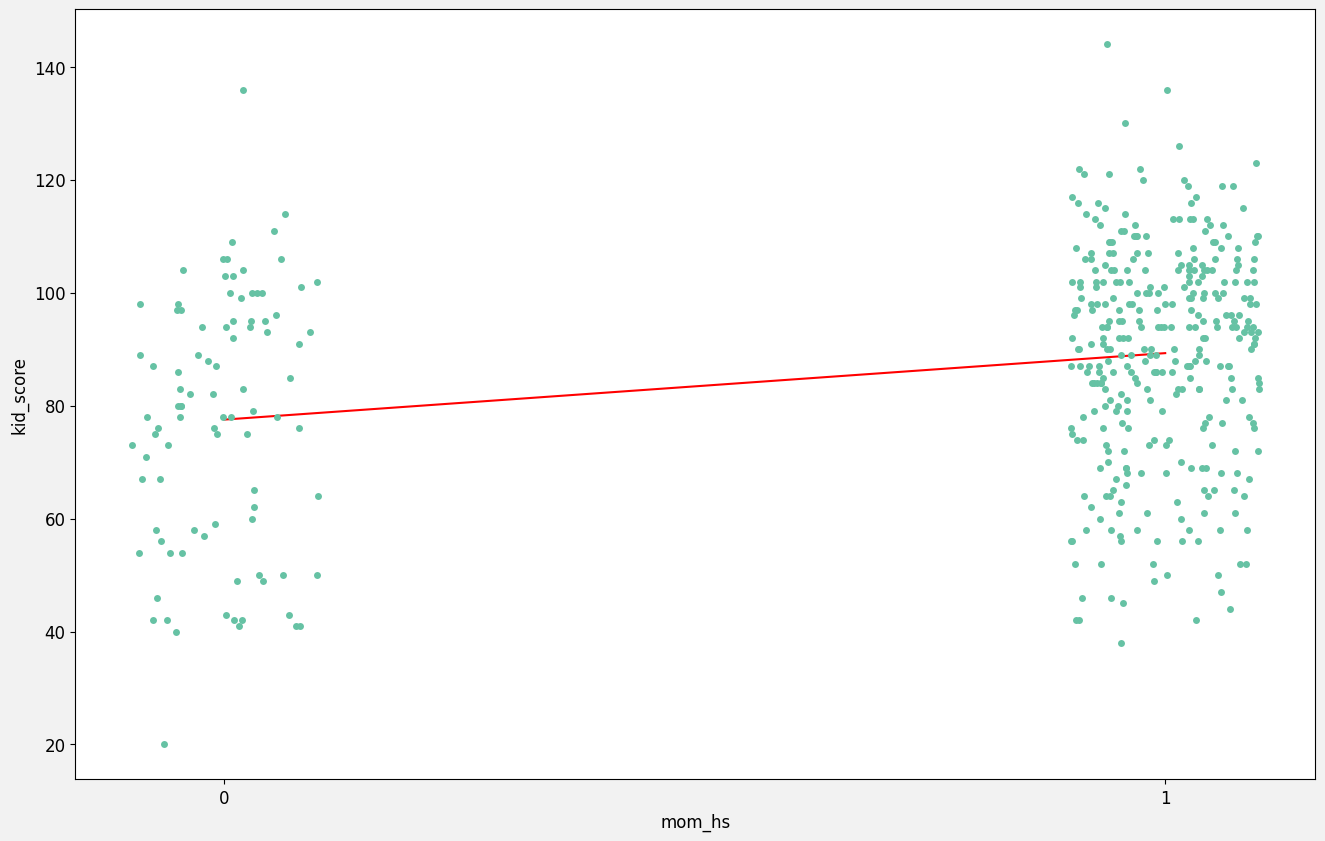

In [5]:
fig, ax = plt.subplots()
sns.stripplot(x = 'mom_hs', y = 'kid_score', data = iq, jitter = True, ax = ax)
ax.plot(x_line, y_line, color = 'red')
plt.show()

In [6]:
# Continuous:
mod2 = smf.ols(formula = 'kid_score ~ mom_iq', data = iq).fit()
mod2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              kid_score   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     108.6
Date:                Tue, 05 Dec 2023   Prob (F-statistic):           7.66e-23
Time:                        16:59:17   Log-Likelihood:                -1875.6
No. Observations:                 434   AIC:                             3755.
Df Residuals:                     432   BIC:                             3763.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.7998      5.917      4.360      0.000      14.169      37.430
mom_iq         0.6100      0.059     10.423      0.000       0.495       0.725
==============================================================================
Omnibus:                        7.545   Durbin-Watson:                   1.645
Prob(Omnibus):                  0.023   Jarque-Bera (JB):                7.735
Skew:                          -0.324   Prob(JB):                       0.0209
Kurtosis:                       2.919   Cond. No.                         682.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

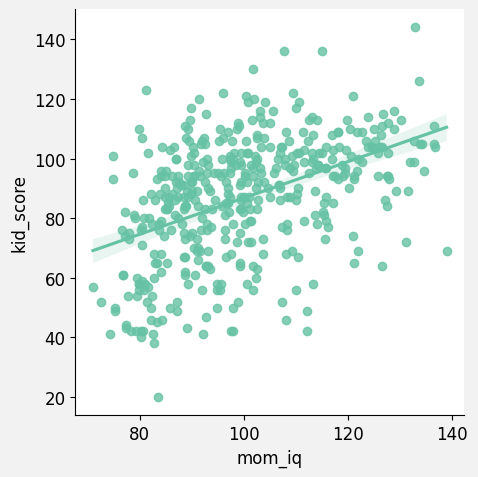

In [7]:
sns.lmplot(x = 'mom_iq', y = 'kid_score', data = iq)
plt.show()

In [8]:
# Both predictors (binary and continuous):
mod3 = smf.ols(formula = 'kid_score ~ mom_iq + mom_hs', data = iq).fit()
mod3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              kid_score   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     58.72
Date:                Tue, 05 Dec 2023   Prob (F-statistic):           2.79e-23
Time:                        16:59:17   Log-Likelihood:                -1872.0
No. Observations:                 434   AIC:                             3750.
Df Residuals:                     431   BIC:                             3762.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.7315      5.875      4.380      0.000      14.184      37.279
mom_iq         0.5639      0.061      9.309      0.000       0.445       0.683
mom_hs         5.9501      2.212      2.690      0.007       1.603      10.297
==============================================================================
Omnibus:                        7.327   Durbin-Watson:                   1.625
Prob(Omnibus):                  0.026   Jarque-Bera (JB):                7.530
Skew:                          -0.313   Prob(JB):                       0.0232
Kurtosis:                       2.845   Cond. No.                         683.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

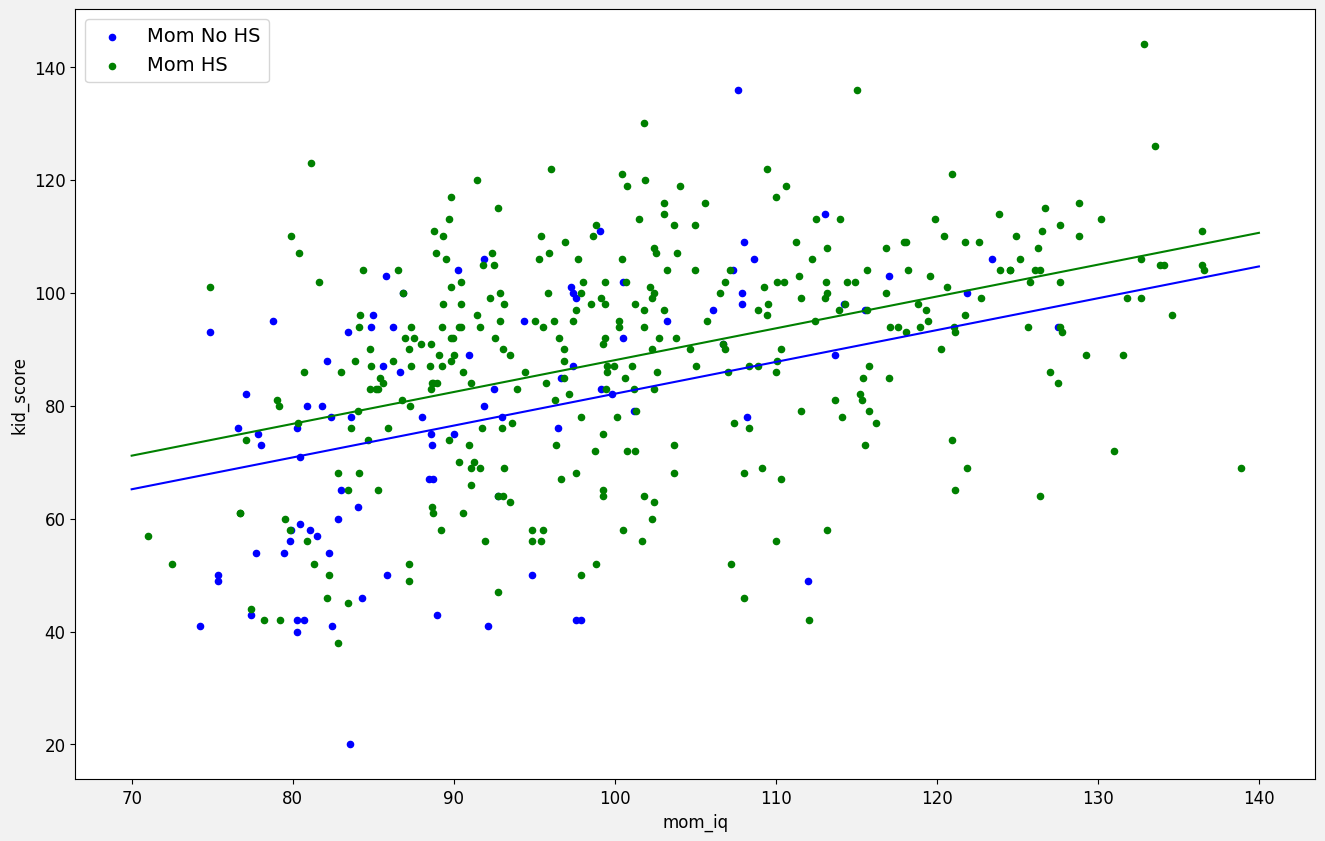

In [9]:
# Plotting the results:
a_hat = mod3.params.iloc[0]
b1_hat = mod3.params.iloc[1]
b2_hat = mod3.params.iloc[2]

x_line = np.linspace(70, 140, 200)
y_line_noHS = a_hat + b1_hat * x_line
y_line_HS = a_hat + b1_hat * x_line + b2_hat

fig, ax = plt.subplots()
iq.loc[iq['mom_hs'] == 0].plot.scatter('mom_iq', 'kid_score', label = 'Mom No HS', color = 'blue', ax = ax)
iq.loc[iq['mom_hs'] == 1].plot.scatter('mom_iq', 'kid_score', label = 'Mom HS', color = 'green', ax = ax)
ax.plot(x_line, y_line_noHS, color = 'blue')
ax.plot(x_line, y_line_HS, color = 'green')
plt.show()

### Interactions

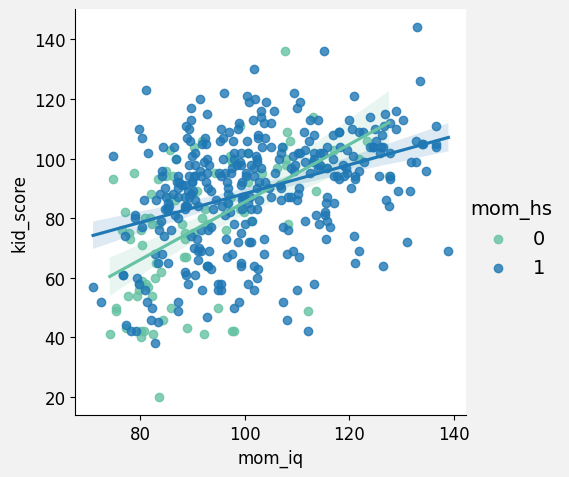

In [10]:
sns.lmplot(x = 'mom_iq', y = 'kid_score', hue = 'mom_hs', data = iq)
plt.show()

With interactions in mind, we want to estimate this regression equation: <br> $kid\_score_{i} = b_{0} + b_{1}mom\_hs_{i} + b_{2}mom\_hs_{i} + b_{3}mom\_hs_{i} \times mom\_iq_{i} + \epsilon_{i}$

In [11]:
mod4 = smf.ols('kid_score ~ mom_iq + mom_hs + mom_iq:mom_hs', data = iq).fit()
mod4 = smf.ols('kid_score ~ mom_iq*mom_hs', data = iq).fit() # Shorthand
mod4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              kid_score   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     42.84
Date:                Tue, 05 Dec 2023   Prob (F-statistic):           3.07e-24
Time:                        16:59:19   Log-Likelihood:                -1867.5
No. Observations:                 434   AIC:                             3743.
Df Residuals:                     430   BIC:                             3759.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       -11.4820     13.758     -0.835      0.404     -38.523      15.559
mom_iq            0.9689      0.148      6.531      0.000       0.677       1.260
mom_hs           51.2682     15.338      3.343      0.001      21.122      81.414
mom_iq:mom_hs    -0.4843      0.162     -2.985      0.003      -0.803      -0.165
==============================================================================
Omnibus:                        8.014   Durbin-Watson:                   1.660
Prob(Omnibus):                  0.018   Jarque-Bera (JB):                8.258
Skew:                          -0.333   Prob(JB):                       0.0161
Kurtosis:                       2.887   Cond. No.                     3.10e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.1e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

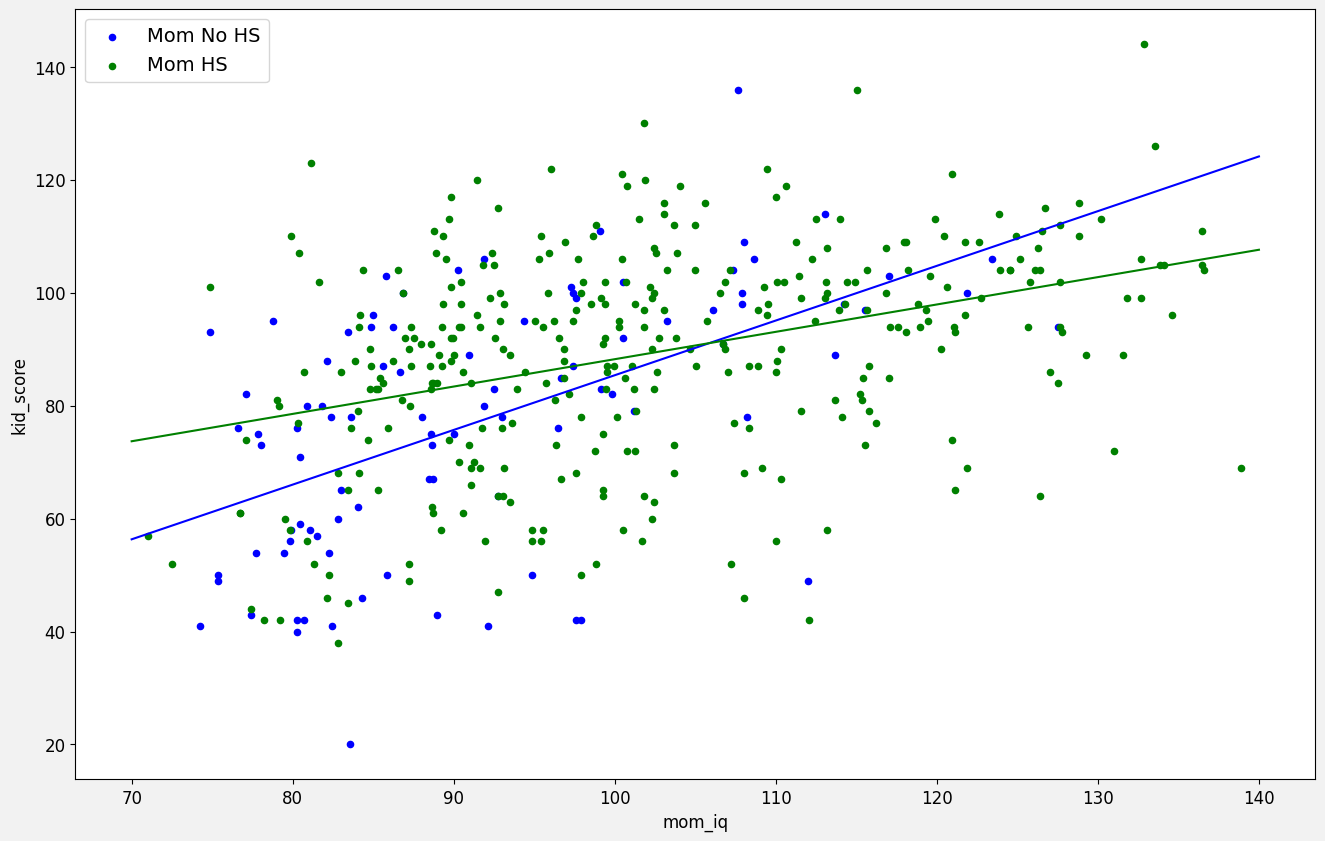

In [12]:
b0_hat = mod4.params.iloc[0]
b1_hat = mod4.params.iloc[1]
b2_hat = mod4.params.iloc[2]
b3_hat = mod4.params.iloc[3]

x_line = np.linspace(70, 140, 200)
y_line_noHS = b0_hat + b1_hat * x_line
y_line_HS = b0_hat + b2_hat + (b1_hat + b3_hat) * x_line

fig, ax = plt.subplots()
iq.loc[iq['mom_hs'] == 0].plot.scatter('mom_iq', 'kid_score', label = 'Mom No HS', color = 'blue', ax = ax)
iq.loc[iq['mom_hs'] == 1].plot.scatter('mom_iq', 'kid_score', label = 'Mom HS', color = 'green', ax = ax)
ax.plot(x_line, y_line_noHS, color = 'blue')
ax.plot(x_line, y_line_HS, color = 'green')
plt.show()

b0 and b1 (I drop the ^ notation - just assume we are talking about the estimates now) are the intercept and slope of the line for the relationship between test score and mom's iq for children with mothers without a high school education. Again, giving an interpretation to b0 is quite meaningless when the actual values of mom_iq do not get close to zero.

The sum (b0+b2) can be interpreted as the intercept of the relationship between mom's iq and the kids's score for children with a high-school educated mother.

The sum (b1+b3) is the slope of this line. Thus the interaction effect (b3) can be interpreted as the increase/decrease in the slope for children with high-school educated mothers.

### Using a "real" data set

In [13]:
pv = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/pv_csi_new.csv", index_col=0)
pv.head()

,manufacturer,csi_id,csi_complete,prog_administrator,program,csi_cost,incentive_design,nameplate,incentive_type,sector,csi_rating,cec_ptc_rating,incentive_step,incentive_amount,incentive_app_status,MASH_1A,MASH_1B,MASH_2,contractor,contractor_id,csi_3rd_party,city,county,state,zip,month,year,cost_per_kw,year_totals,manuf_year_total,manuf_market_share,contractor_year_total,contractor_market_share,county_year_total,lease,cost_ex_subsid_per_kw,date,time_days,time_years,time_days_sq,time_days_cu,time_years_sq,time_years_cu,year_num_total,manuf_count,nationality,china
1,1Soltech,SCE-CSI-64076,2014-01-20,SCE,Small Commercial (< 10 kW) and All Residential,25520.0,$0.20 per Watt EPBB,3.36,EPBB,Residential,2.813,2.817,Step 10,563.0,Completed,NaN,NaN,NaN,AMERICAN SOLAR CONSTRUCTION & HOME REMODELING ...,504952,no,Arcadia,Los Angeles,CA,91006,1,2014,7595.238095,233876.027,57.36,0.000245,471.985,0.002018,39359.931,0,7427.678571,2014-01-20,2526,6.920548,6380676.0,1.611759e+10,47.893984,331.452612,21376,15.0,NaN,NaN
2,1Soltech,SCE-CSI-57960,2013-12-05,SCE,Small Commercial (< 10 kW) and All Residential,30000.0,$0.20 per Watt EPBB,5.04,EPBB,Residential,4.227,4.248,Step 10,845.0,Completed,NaN,NaN,NaN,AMERICAN SOLAR CONSTRUCTION & HOME REMODELING ...,504952,no,Lancaster,Los Angeles,CA,93536,12,2013,5952.380952,239711.622,32.10,0.000134,216.675,0.000904,32107.461,0,5784.722222,2013-12-05,2480,6.794521,6150400.0,1.525299e+10,46.165509,313.672503,30295,15.0,NaN,NaN
3,1Soltech,SCE-CSI-65160,2013-12-13,SCE,Small Commercial (< 10 kW) and All Residential,32000.0,$0.20 per Watt EPBB,4.08,EPBB,Residential,3.027,3.421,Step 10,605.0,Completed,NaN,NaN,NaN,AMERICAN SOLAR CONSTRUCTION & HOME REMODELING ...,504952,no,Rialto,San Bernardino,CA,92377,12,2013,7843.137255,239711.622,32.10,0.000134,216.675,0.000904,19223.502,0,7694.852941,2013-12-13,2488,6.816438,6190144.0,1.540108e+10,46.463832,316.717846,30295,15.0,NaN,NaN
4,1Soltech,SCE-CSI-64202,2014-03-05,SCE,Small Commercial (< 10 kW) and All Residential,32500.0,$0.20 per Watt EPBB,4.94,EPBB,Residential,3.916,4.243,Step 10,783.0,Completed,NaN,NaN,NaN,AMERICAN SOLAR CONSTRUCTION & HOME REMODELING ...,504952,no,Temecula,Riverside,CA,92592,3,2014,6578.947368,233876.027,57.36,0.000245,471.985,0.002018,37860.350,0,6420.445344,2014-03-05,2570,7.041096,6604900.0,1.697459e+10,49.577031,349.076632,21376,15.0,NaN,NaN
5,1Soltech,SCE-CSI-65179,2014-02-25,SCE,Small Commercial (< 10 kW) and All Residential,32500.0,$0.20 per Watt EPBB,5.04,EPBB,Residential,3.761,4.248,Step 10,752.0,Completed,NaN,NaN,NaN,AMERICAN SOLAR CONSTRUCTION & HOME REMODELING ...,504952,no,Lakewood,Los Angeles,CA,90712,2,2014,6448.412698,233876.027,57.36,0.000245,471.985,0.002018,39359.931,0,6299.206349,2014-02-25,2562,7.019178,6563844.0,1.681657e+10,49.268861,345.826909,21376,15.0,NaN,NaN


In [14]:
pv.dtypes

manufacturer                object
csi_id                      object
csi_complete                object
prog_administrator          object
program                     object
csi_cost                   float64
incentive_design            object
nameplate                  float64
incentive_type              object
sector                      object
csi_rating                 float64
cec_ptc_rating             float64
incentive_step              object
incentive_amount           float64
incentive_app_status        object
MASH_1A                    float64
MASH_1B                    float64
MASH_2                     float64
contractor                  object
contractor_id                int64
csi_3rd_party               object
city                        object
county                      object
state                       object
zip                          int64
month                        int64
year                         int64
cost_per_kw                float64
year_totals         

##### Working with dates

In [15]:
pv['date']

1         2014-01-20
2         2013-12-05
3         2013-12-13
4         2014-03-05
5         2014-02-25
             ...    
106547    2014-08-15
106548    2013-06-06
106549    2013-06-12
106550    2014-06-23
106551    2014-06-30
Name: date, Length: 106551, dtype: object

In [16]:
pv['date'] = pd.to_datetime(pv['date'], format = '%Y-%m-%d')

In [17]:
pv = pv.sort_values(by = ['date'], ascending = True)

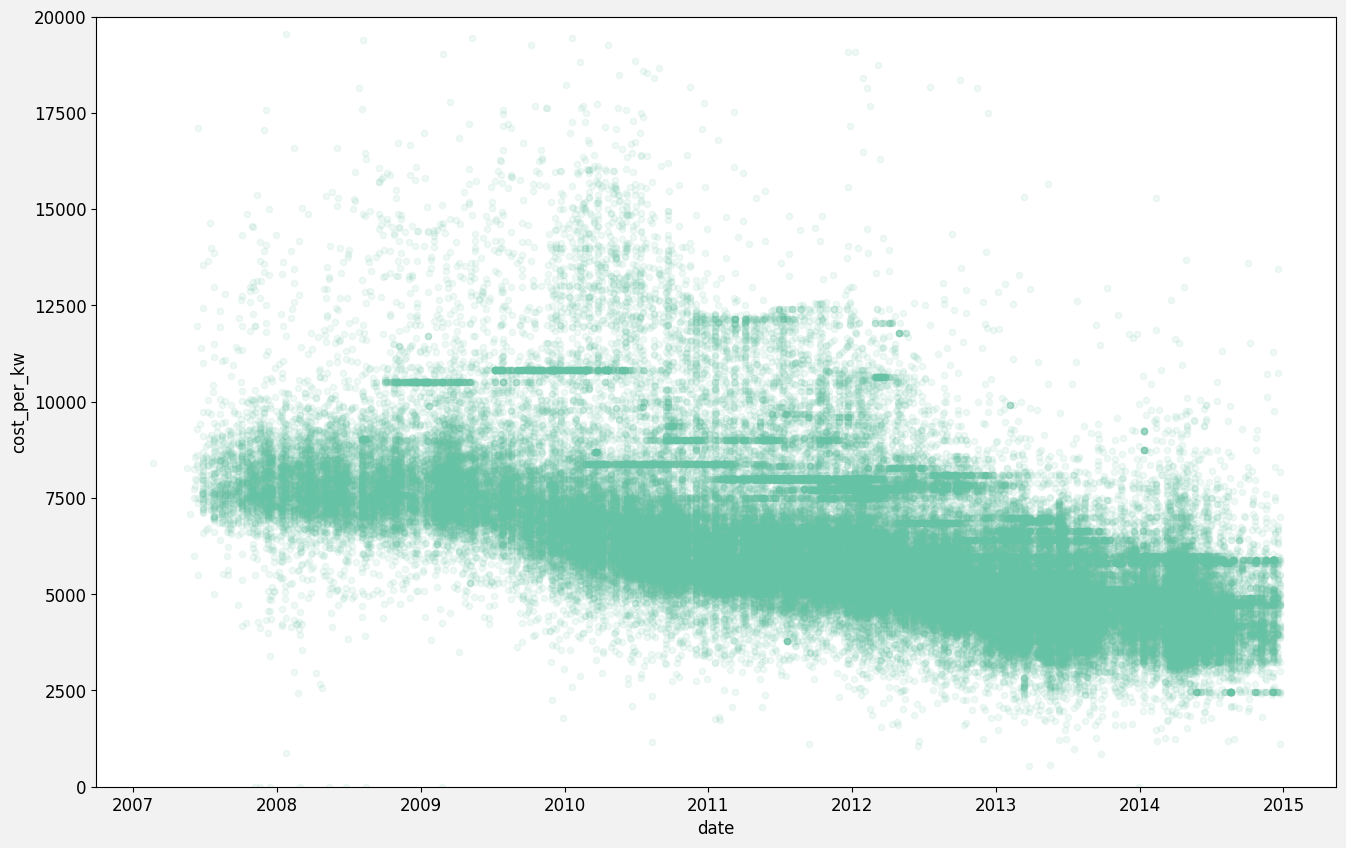

In [18]:
fig, ax = plt.subplots()
pv.plot.scatter('date', 'cost_per_kw', alpha = .1, ax = ax)
ax.set_ylim(0, 20000)
plt.show()

In [19]:
mod1 = smf.ols('cost_per_kw ~ time_days', data = pv).fit()
mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            cost_per_kw   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                 5.287e+04
Date:                Tue, 05 Dec 2023   Prob (F-statistic):               0.00
Time:                        16:59:26   Log-Likelihood:            -9.4192e+05
No. Observations:              106551   AIC:                         1.884e+06
Df Residuals:                  106549   BIC:                         1.884e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   9467.8113     15.208    622.547      0.000    9438.003    9497.619
time_days     -1.8202      0.008   -229.945      0.000      -1.836      -1.805
==============================================================================
Omnibus:                   164379.725   Durbin-Watson:                   1.863
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        571053178.058
Skew:                           9.018   Prob(JB):                         0.00
Kurtosis:                     361.191   Cond. No.                     5.71e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.71e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [20]:
import datetime
T = (pv['date'].iloc[-1] - pv['date'].iloc[0]).days + 1

base = pv['date'].iloc[0]
date_list = [base + datetime.timedelta(days = x) for x in range(T)]
fake_dates = pd.to_datetime(pd.Series([date.strftime('%Y-%m-%d') for date in date_list]))

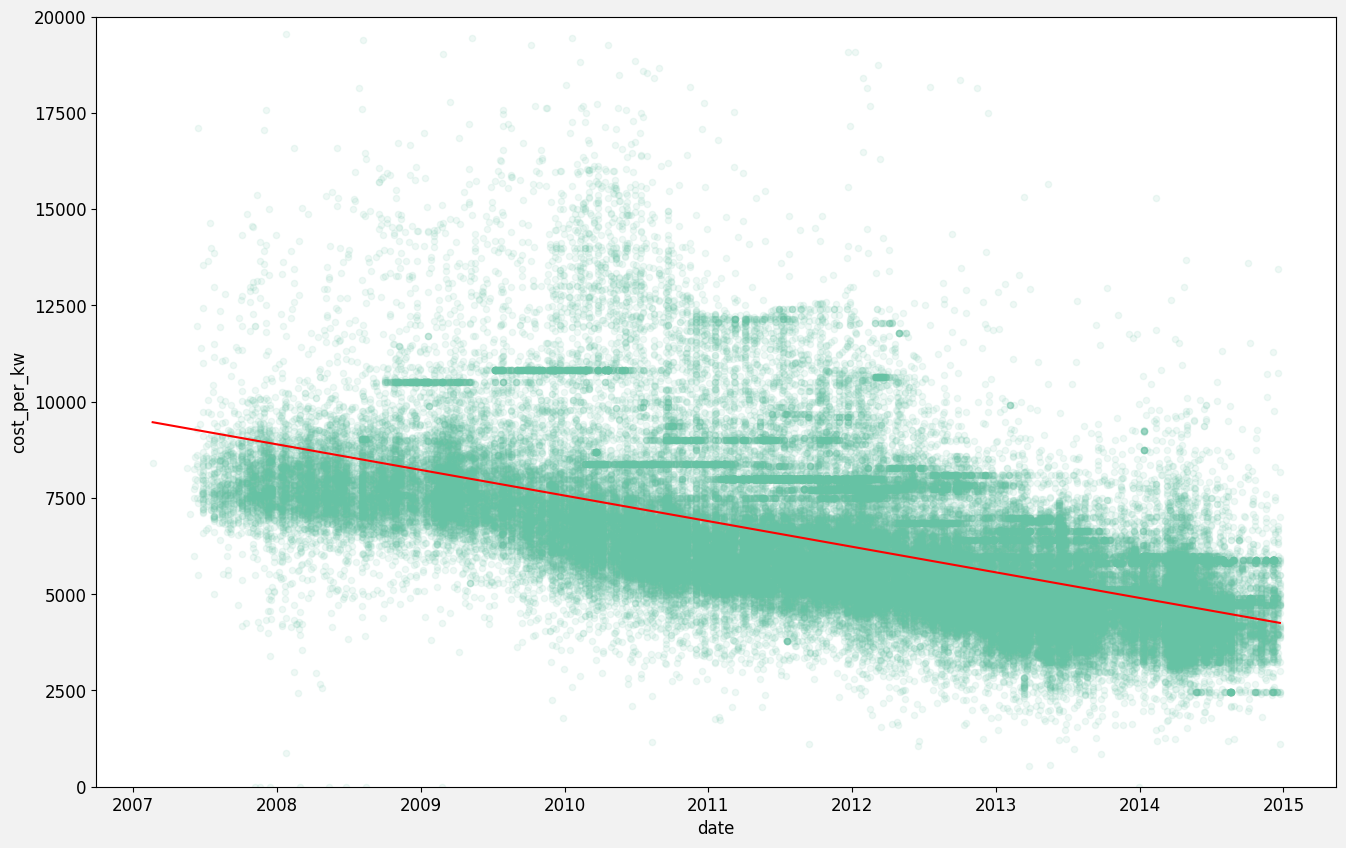

In [21]:
x_line = np.linspace(0, T, T)
y_line = mod1.params.iloc[0] + mod1.params.iloc[1] * x_line

fig, ax = plt.subplots()
pv.plot.scatter('date', 'cost_per_kw', alpha = .1, ax = ax)
ax.set_ylim(0, 20000)
ax.plot(fake_dates, y_line, color = 'red')
plt.show()

In [22]:
# de-meaned time trend:
pv['time_days_m'] = pv['time_days'] - np.mean(pv['time_days'])

In [23]:
# Including China in the model:
mod2 = smf.ols('cost_per_kw ~ time_days_m + china', data = pv).fit()
mod2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            cost_per_kw   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                 2.661e+04
Date:                Tue, 05 Dec 2023   Prob (F-statistic):               0.00
Time:                        16:59:28   Log-Likelihood:            -9.2773e+05
No. Observations:              104992   AIC:                         1.855e+06
Df Residuals:                  104989   BIC:                         1.856e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    6267.0085      6.247   1003.157      0.000    6254.764    6279.253
time_days_m    -1.7324      0.009   -198.668      0.000      -1.750      -1.715
china        -315.4043     12.485    -25.262      0.000    -339.876    -290.933
==============================================================================
Omnibus:                   163523.573   Durbin-Watson:                   1.862
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        597023260.551
Skew:                           9.191   Prob(JB):                         0.00
Kurtosis:                     371.965   Cond. No.                     1.64e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.64e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

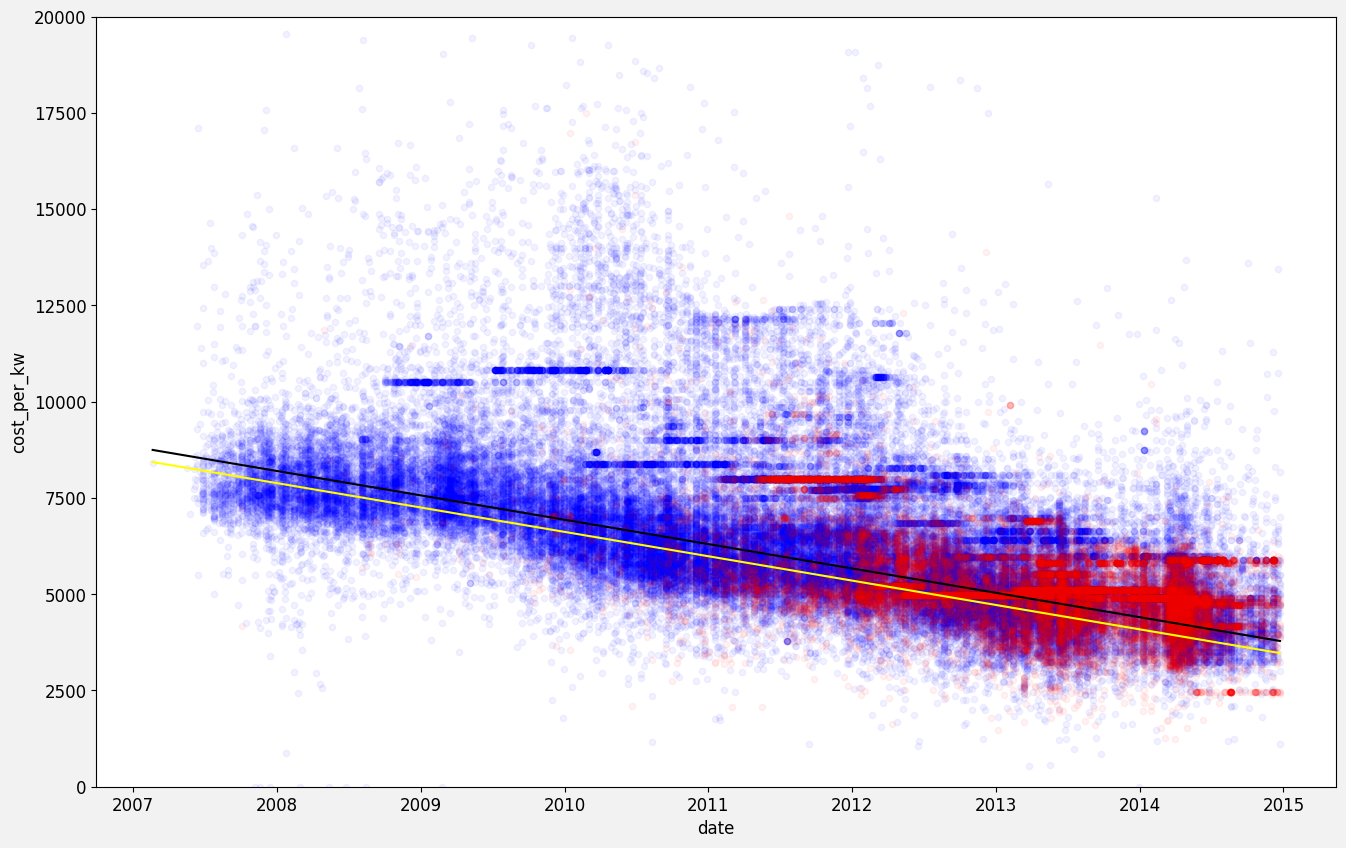

In [24]:
# Plotting model 2:
x_line = np.linspace(0, T, T)
x_line_m = x_line -np.mean(x_line)
y_line = mod2.params.iloc[0] + mod2.params.iloc[1] * x_line_m
y_line_china = mod2.params.iloc[0] + mod2.params.iloc[1] * x_line_m + mod2.params.iloc[2]

fig, ax = plt.subplots()
pv.loc[pv['china'] == 0].plot.scatter('date', 'cost_per_kw', alpha = .05, color = 'blue', ax = ax)
pv.loc[pv['china'] == 1].plot.scatter('date', 'cost_per_kw', alpha = .05, color = 'red', ax = ax)
ax.set_ylim(0, 20000)
ax.plot(fake_dates, y_line, color = 'black')
ax.plot(fake_dates, y_line_china, color = 'yellow')
plt.show()

In [25]:
# Allowing for different slopes:
mod3 = smf.ols('cost_per_kw ~ time_days_m * china', data = pv).fit()
mod3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            cost_per_kw   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.337
Method:                 Least Squares   F-statistic:                 1.775e+04
Date:                Tue, 05 Dec 2023   Prob (F-statistic):               0.00
Time:                        16:59:31   Log-Likelihood:            -9.2772e+05
No. Observations:              104992   AIC:                         1.855e+06
Df Residuals:                  104988   BIC:                         1.855e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          6264.3207      6.268    999.483      0.000    6252.036    6276.605
time_days_m          -1.7485      0.009   -189.166      0.000      -1.767      -1.730
china              -367.3554     15.947    -23.036      0.000    -398.611    -336.100
time_days_m:china     0.1458      0.028      5.236      0.000       0.091       0.200
==============================================================================
Omnibus:                   163535.633   Durbin-Watson:                   1.861
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        596789245.227
Skew:                           9.192   Prob(JB):                         0.00
Kurtosis:                     371.892   Cond. No.                     2.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

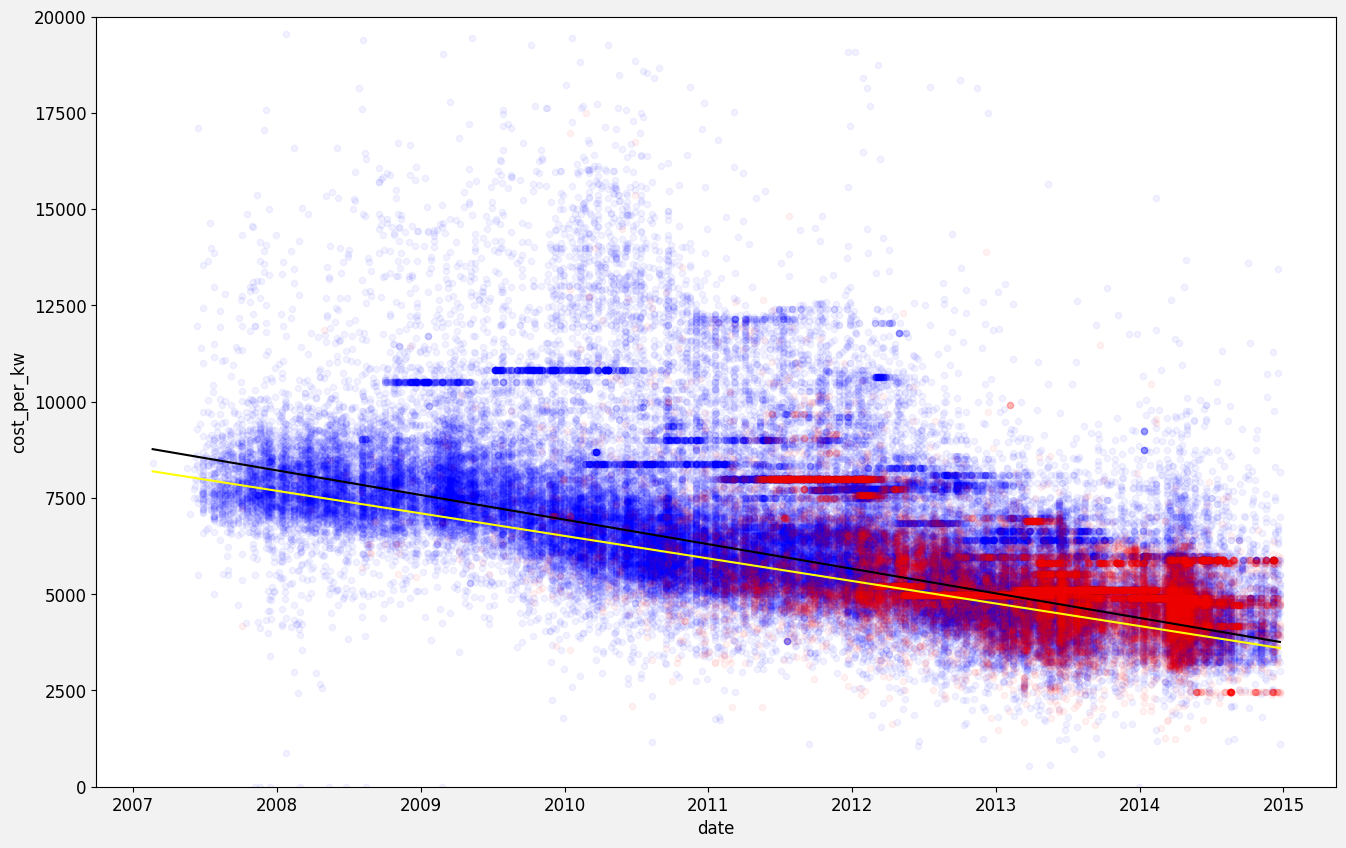

In [26]:
# Plotting model 3:
b0_hat = mod3.params.iloc[0]
b1_hat = mod3.params.iloc[1]
b2_hat = mod3.params.iloc[2]
b3_hat = mod3.params.iloc[3]

x_line = np.linspace(0, T, T)
x_line_m = x_line -np.mean(x_line)
y_line = b0_hat + b1_hat * x_line_m
y_line_china = b0_hat + b2_hat + (b1_hat + b3_hat) * x_line_m

fig, ax = plt.subplots()
pv.loc[pv['china'] == 0].plot.scatter('date', 'cost_per_kw', alpha = .05, color = 'blue', ax = ax)
pv.loc[pv['china'] == 1].plot.scatter('date', 'cost_per_kw', alpha = .05, color = 'red', ax = ax)
ax.set_ylim(0, 20000)
ax.plot(fake_dates, y_line, color = 'black')
ax.plot(fake_dates, y_line_china, color = 'yellow')
plt.show()

### Indicator variables

In [27]:
pv['sector'].unique()

array(['Government', 'Residential', 'Commercial', 'Non-Profit'],
      dtype=object)

In [28]:
# Including sector indicators in model:
mod4 = smf.ols('cost_per_kw ~ time_days_m * china + sector', data = pv).fit()
mod4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            cost_per_kw   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     8953.
Date:                Tue, 05 Dec 2023   Prob (F-statistic):               0.00
Time:                        16:59:34   Log-Likelihood:            -9.2757e+05
No. Observations:              104992   AIC:                         1.855e+06
Df Residuals:                  104985   BIC:                         1.855e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              6027.1166     41.558    145.028      0.000    5945.663    6108.570
sector[T.Government]   1590.6131     98.156     16.205      0.000    1398.228    1782.998
sector[T.Non-Profit]   -304.4859     96.484     -3.156      0.002    -493.593    -115.379
sector[T.Residential]   237.7904     41.838      5.684      0.000     155.789     319.792
time_days_m              -1.7488      0.009   -189.432      0.000      -1.767      -1.731
china                  -364.6179     15.925    -22.895      0.000    -395.831    -333.404
time_days_m:china         0.1429      0.028      5.138      0.000       0.088       0.197
==============================================================================
Omnibus:                   163769.442   Durbin-Watson:                   1.862
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        603402067.653
Skew:                           9.218   Prob(JB):                         0.00
Kurtosis:                     373.933   Cond. No.                     1.45e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.45e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Statsmodels creates dummy variables for each unique value of the indicator variable. One indicator is omitted (commercial), it gets absorbed into the intercept, and is now the comparison value. You compare ech other coefficient to the commercial. Government costs 1590 usd more than a comparable system on a commercial building.

### Non-linear time trend

Add a quadratic time trend to the model: <br>
$cost\_per\_kw_i = b_0t_i + b_0t_i^2 + XB + \epsilon_i$

In [29]:
# Create a quadratic term:
pv['time_days_m_sq'] = pv['time_days_m'] ** 2

In [30]:
# Not adding interaction between the trend terms and china here:
mod5 = smf.ols('cost_per_kw ~ time_days_m + time_days_m_sq', data = pv).fit()
mod5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            cost_per_kw   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                 2.688e+04
Date:                Tue, 05 Dec 2023   Prob (F-statistic):               0.00
Time:                        16:59:34   Log-Likelihood:            -9.4162e+05
No. Observations:              106551   AIC:                         1.883e+06
Df Residuals:                  106548   BIC:                         1.883e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       6290.8428      6.985    900.577      0.000    6277.152    6304.534
time_days_m       -1.9218      0.009   -215.208      0.000      -1.939      -1.904
time_days_m_sq    -0.0003   1.14e-05    -24.333      0.000      -0.000      -0.000
==============================================================================
Omnibus:                   165044.969   Durbin-Watson:                   1.873
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        591611598.739
Skew:                           9.087   Prob(JB):                         0.00
Kurtosis:                     367.591   Cond. No.                     8.99e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.99e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

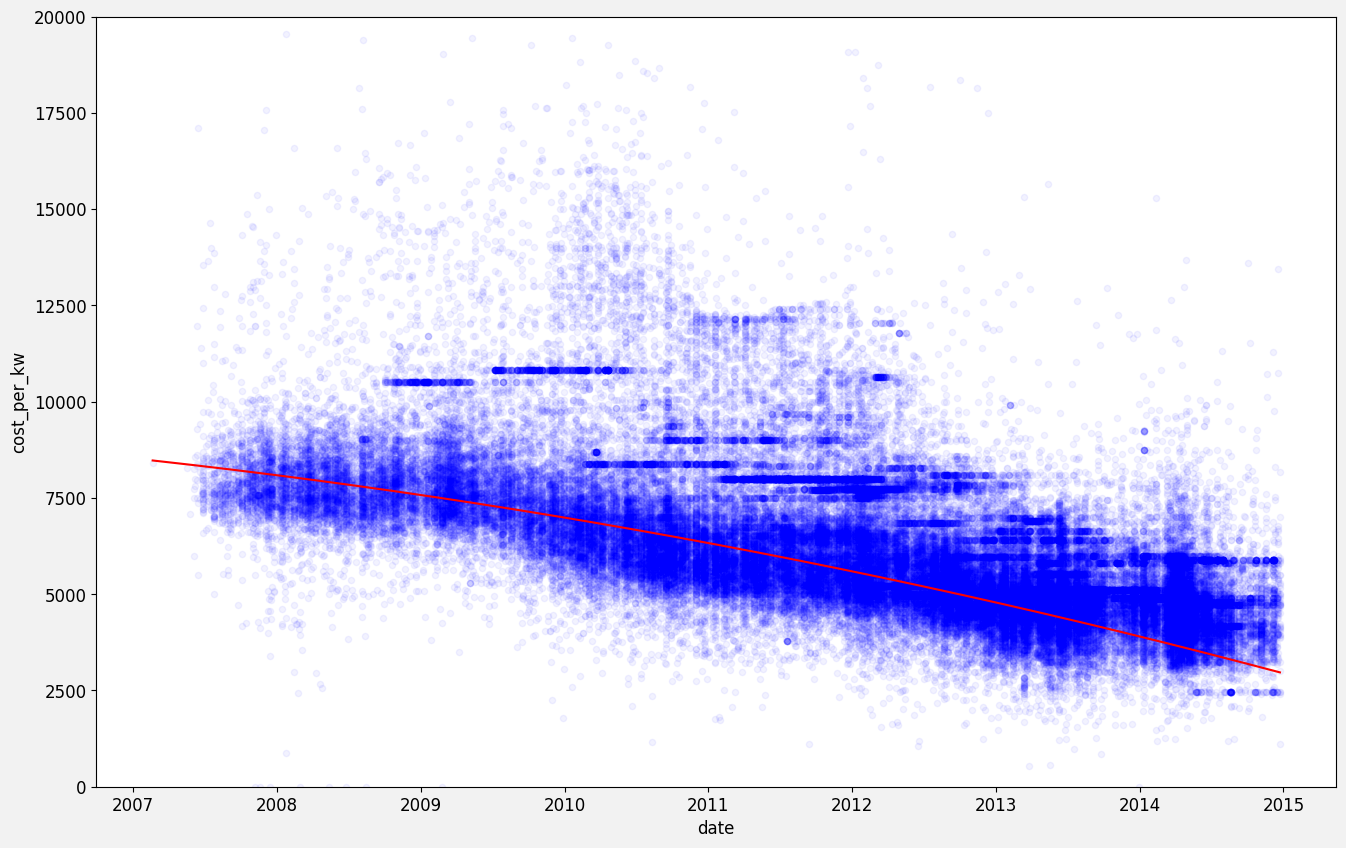

In [31]:
# Visualizing the model:
b0_hat = mod5.params.iloc[0]
b1_hat = mod5.params.iloc[1]
b2_hat = mod5.params.iloc[2]

x_line = np.linspace(0, T, T)
x_line_m = x_line - np.mean(x_line)
y_line = b0_hat + b1_hat * x_line_m + b2_hat * x_line_m ** 2

fig, ax = plt.subplots()
pv.plot.scatter('date', 'cost_per_kw', alpha = .05, color = 'blue', ax = ax)
ax.set_ylim(0, 20000)
ax.plot(fake_dates, y_line, color = 'red')
plt.show()

This tends to give bad out-of-sample predictions. If we were to predict for 2016, the result could not necessarily be trusted.

### Simulation and visualisation of uncertainty and plotting data

Representing uncertainty for a linear model, you can use the standard error of the estimate, but for a quadratic trend line it is difficult to represent the uncertainty on the two standard errors of the estimates. Instead we use simulation.

##### Inferential uncertainty

In [32]:
# Covariance matrix:
nmk = mod5.df_resid
sigma_hat = np.sqrt(mod5.mse_resid)
bs_vcov = mod5.cov_params(scale = 1)
bs = mod5.params
bs_vcov

,Intercept,time_days_m,time_days_m_sq
Intercept,1.757302e-05,-7.169207e-09,-1.957946e-11
time_days_m,-7.169207e-09,2.871991e-11,1.714360e-14
time_days_m_sq,-1.957946e-11,1.714360e-14,4.682003e-17


In [33]:
sigma_sim = sigma_hat * np.sqrt((nmk / np.random.chisquare(nmk, 1)))

In [34]:
V_sim = np.array(bs_vcov) * sigma_sim ** 2
V_sim

array([[ 4.88797478e+01, -1.99413042e-02, -5.44606910e-05],
       [-1.99413042e-02,  7.98850525e-05,  4.76853028e-08],
       [-5.44606910e-05,  4.76853028e-08,  1.30230928e-10]])

In [35]:
beta_sim = np.random.multivariate_normal(bs, V_sim, 1)
beta_sim

array([[ 6.30388134e+03, -1.92703461e+00, -2.93014391e-04]])

In [36]:
# Putting the simulation above into a function to be able to call the simulation multiple times. 
def regSim(regMod):
    nmk = regMod.df_resid
    sigma_hat = np.sqrt(regMod.mse_resid / nmk)
    bs_vcov = regMod.cov_params()
    bs = regMod.params

    sigma_sim = sigma_hat * np.sqrt(nmk / np.random.chisquare(nmk, 1))
    V_sim = np.array(bs_vcov) * sigma_sim ** 2
    beta_sim = np.random.multivariate_normal(bs, V_sim, 1)

    return beta_sim.flatten()

In [37]:
# Creating 50 simulations:
nsim = 50
beta_sims = []
sigma_sims = []

for s in range(nsim):
    beta_sims.append(regSim(mod5))

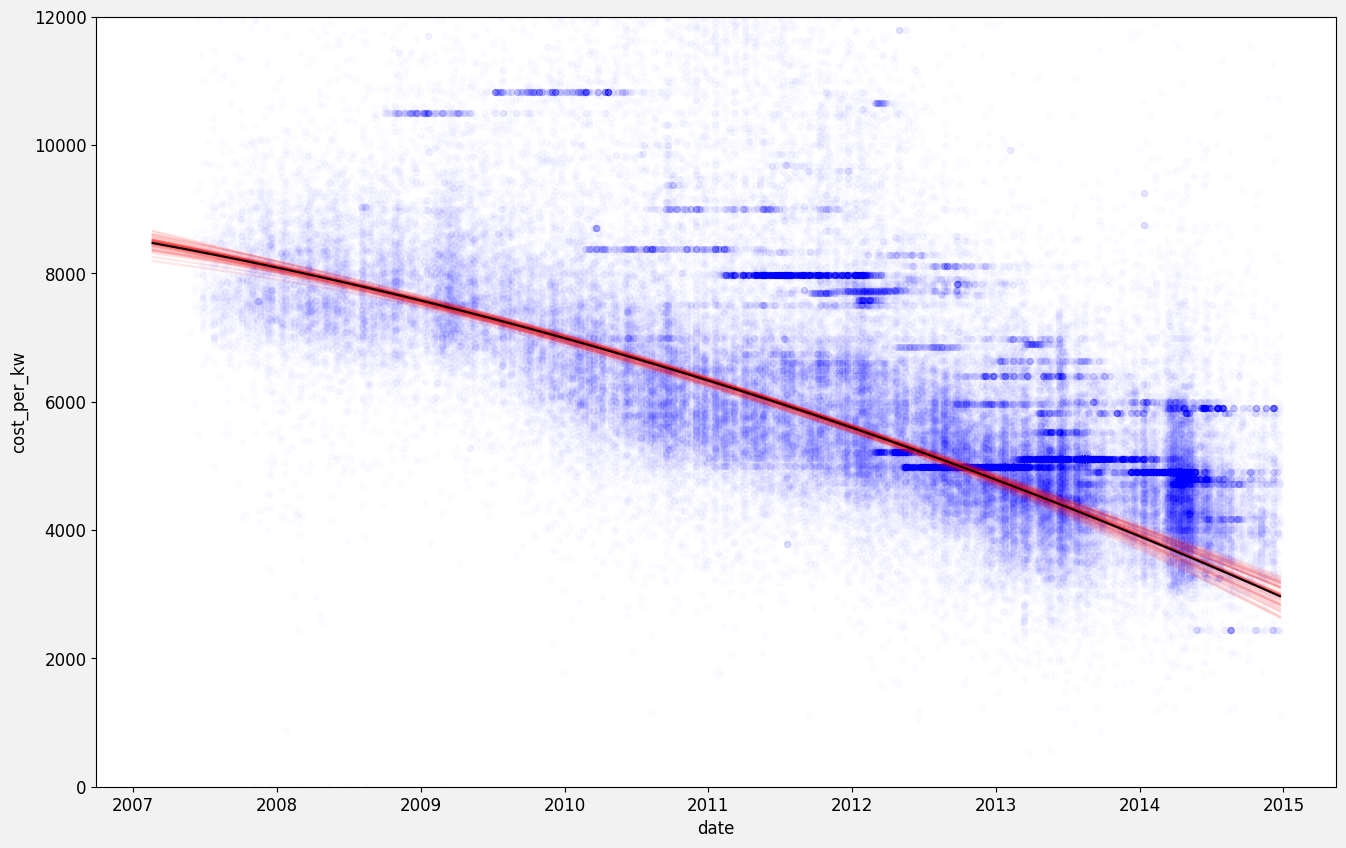

In [38]:
fig, ax = plt.subplots()
pv.plot.scatter('date', 'cost_per_kw', alpha = .01, color = 'blue', ax = ax)
ax.set_ylim(0, 12000)
ax.plot(fake_dates, y_line, color = 'black', zorder = 10)

for i in range(nsim):
    y_line_sim = beta_sims[i][0] + beta_sims[i][1] * x_line_m + beta_sims[i][2] * x_line_m **2
    ax.plot(fake_dates, y_line_sim, color = 'red', alpha = .1)

plt.show()

Inferential uncertainty tells us about the uncertainty about the value of the parameter (in this case date/time). If we want to express the uncertainty of actually predicting the cost per kw based on the date, we use predictive uncertainty which takes into account the estimated standard error of the model. 

##### Predictive uncertainty

Inferential uncertainty indicates the uncertainty of the regression line, the uncertainty about the mean value given any certain date. To measure the uncertainty that takes into account the value of any given data point, we need to estimate the predictive uncertainty, to do this we just include uncertainty that is contained in the model's estimated sigma.

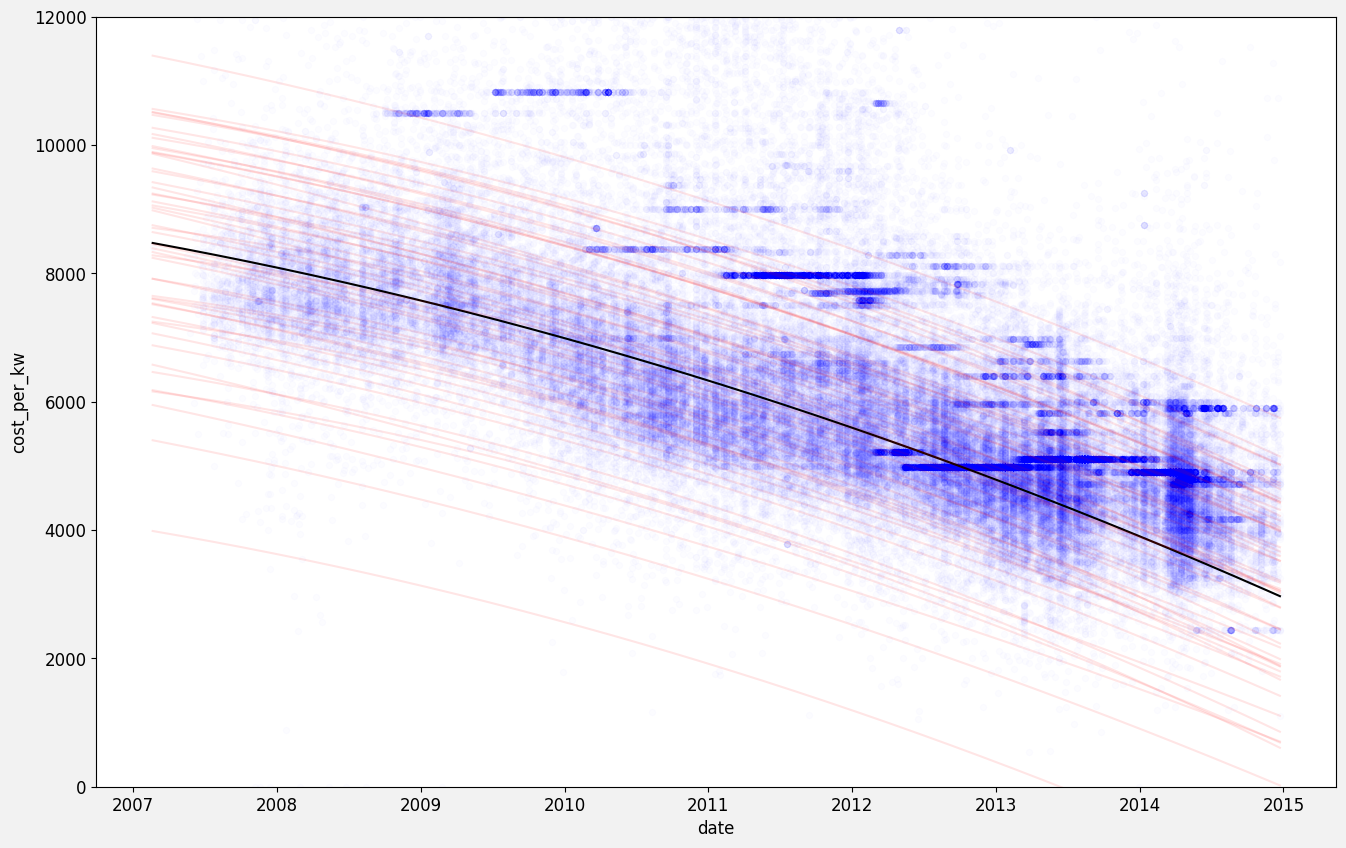

In [39]:
fig, ax = plt.subplots()
pv.plot.scatter('date', 'cost_per_kw', alpha = .01, color = 'blue', ax = ax)
ax.set_ylim(0, 12000)
ax.plot(fake_dates, y_line, color = 'black')

for i in range(nsim):
    y_line_sim = beta_sims[i][0] + beta_sims[i][1] * x_line_m + beta_sims[i][2] * x_line_m ** 2 + np.random.normal(0, sigma_hat)
    ax.plot(fake_dates, y_line_sim, color = 'red', alpha = .1)

plt.show()

In [40]:
mod6 = smf.ols('cost_per_kw ~ time_days_m + time_days_m_sq + china + sector + county_year_total + contractor_year_total', data = pv).fit()
mod6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            cost_per_kw   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     6869.
Date:                Tue, 05 Dec 2023   Prob (F-statistic):               0.00
Time:                        16:59:42   Log-Likelihood:            -9.2716e+05
No. Observations:              104992   AIC:                         1.854e+06
Df Residuals:                  104983   BIC:                         1.854e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              6073.6634     41.978    144.689      0.000    5991.388    6155.939
sector[T.Government]   1570.6362     97.794     16.061      0.000    1378.961    1762.311
sector[T.Non-Profit]   -302.1678     96.112     -3.144      0.002    -490.547    -113.789
sector[T.Residential]   178.1444     41.783      4.264      0.000      96.251     260.038
time_days_m              -1.9835      0.013   -154.870      0.000      -2.009      -1.958
time_days_m_sq           -0.0003   1.21e-05    -27.128      0.000      -0.000      -0.000
china                  -310.5045     13.834    -22.445      0.000    -337.619    -283.390
county_year_total         0.0107      0.001     17.716      0.000       0.010       0.012
contractor_year_total     0.0020      0.001      3.249      0.001       0.001       0.003
==============================================================================
Omnibus:                   164758.802   Durbin-Watson:                   1.876
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        632148803.525
Skew:                           9.326   Prob(JB):                         0.00
Kurtosis:                     382.677   Cond. No.                     1.43e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.43e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""